In [1]:
import os.path as osp
import sys
sys.path.append('../')
import torch
from torch.utils.data import DataLoader

import numpy as np
import sklearn
from sklearn import preprocessing, metrics, calibration
from tqdm.notebook import tqdm
import types
import copy

import matplotlib
import matplotlib.pyplot as plt

import logging
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)

import utils
import utils.Camel.equations as equations

DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
#DEVICE = 'cpu'
print(DEVICE)

cuda:0


/home/mdrnevich/dev/QuasiML_paper/QuasiML/NegSampleStudy/../utils/__init__.py:5: UserWarning: The recommended fonts to use plothist were not found. You can install them by typing 'install_latin_modern_fonts' in your terminal. 

  from . import plotting


In [2]:
source_mixture_coef = (4, -1)
source_scales = (2.5, 2.3)
target_mixture_coef = (2, -1)
target_scales = (2, 1.2)

source_file = "/data/mdrnevich/ml4nw/NegSampleStudy/base_distribution_data"
target_file = "/data/mdrnevich/ml4nw/NegSampleStudy/target_distribution_data"

sample_ix = 10


STOP_EVENT = int(np.min((np.load(source_file + "_test.npy").shape[0], np.load(target_file + "_test.npy").shape[0])))
test_base_dataset = utils.preprocessing.Dataset(source_file + "_test.npy", 0, stop_event=STOP_EVENT)
test_target_dataset = utils.preprocessing.Dataset(target_file + "_test.npy", 1, stop_event=STOP_EVENT)

test_base_dataset.process(normalize_weights=True)
test_target_dataset.process(normalize_weights=True)

test_generator_data = utils.preprocessing.CombinedDataset(test_base_dataset, test_target_dataset)
print(len(test_generator_data))

test_loader = DataLoader(test_generator_data, batch_size=int(2**10), shuffle=False)
test_nominal_loader = DataLoader(utils.preprocessing.CombinedDataset(test_base_dataset), batch_size=int(2**10), shuffle=False)
test_target_loader = DataLoader(utils.preprocessing.CombinedDataset(test_target_dataset), batch_size=int(2**10), shuffle=False)

7000000


In [3]:
# Get the analytical optimal classifier
s_optimal = equations.optimal_binary_classifier(source_mixture_coef, source_scales, target_mixture_coef, target_scales)

# Load the best models

## Load the SMM model

In [4]:
batch_size = int(2**8)
modpath = osp.join("/data/mdrnevich/ml4nw/NegSampleStudy/models/classifier_SMM_batch{}_sample{}.zip".format(batch_size, sample_ix))
SMM_model = utils.models.load_model(modpath, device=DEVICE).to(DEVICE)
X_scaler_SMM, weight_norm_SMM = utils.preprocessing.load_scaling(modpath)
SMM_model.coefficients

(1.066408395767212, 1.0616191625595093)

In [5]:
print(SMM_model)

MixtureClassifier(
  (subclassifiers): ModuleList(
    (0-3): 4 x Classifier(
      (model): Sequential(
        (0): Linear(in_features=2, out_features=32, bias=True)
        (1): ReLU()
        (2): Linear(in_features=32, out_features=32, bias=True)
        (3): ReLU()
        (4): Linear(in_features=32, out_features=1, bias=True)
        (5): Sigmoid()
      )
    )
  )
)


## Load the $\textrm{SMM}_c$ model

In [6]:
#batch_size = int(2**8)
#modpath = osp.join("models/classifier_SMMc_batch{}.zip".format(batch_size))
#SMMc_model = utils.models.load_model(modpath, device=DEVICE).to(DEVICE)
#X_scaler_SMMc, weight_norm_SMMc = utils.preprocessing.load_scaling(modpath)
#SMMc_model.coefficients

In [7]:
#print(SMMc_model)

## Load the $\textrm{SMM}_r$ model

In [8]:
#batch_size = int(2**8)
#modpath = osp.join("models/classifier_SMMr_batch{}.zip".format(batch_size))
#SMMr_model = utils.models.load_model(modpath, device=DEVICE).to(DEVICE)
#X_scaler_SMMr, weight_norm_SMMr = utils.preprocessing.load_scaling(modpath)
#SMMr_model.coefficients

In [9]:
#print(SMMr_model)

## Load the QDRE classifier

In [10]:
LOSS = "qdre"
batch_size = int(2**8)
modpath = osp.join("/data/mdrnevich/ml4nw/NegSampleStudy/models/classifier_batch{}_sample{}.zip".format(batch_size, sample_ix))
model_new = utils.models.load_model(modpath, device=DEVICE).to(DEVICE)
X_scaler_new, weight_norm_new = utils.preprocessing.load_scaling(modpath)

In [11]:
print(model_new)

Classifier(
  (model): Sequential(
    (0): Linear(in_features=2, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=1, bias=True)
    (5): Sigmoid()
  )
)


# Evaluate the models

## Look at reweighting closure metrics

In [12]:
@torch.no_grad()
def get_r_hats(model, loader, X_scaler=None, weight_norm=1, mix=False, leave=False, classifier="s", labels=None):
    if type(model) is not types.FunctionType:
        model.eval()
        if mix is True:
            loader.collate_fn = lambda batch: utils.preprocessing.prep_inputs_for_training_mix(batch, weight_norm=weight_norm)
        else:
            loader.collate_fn = lambda batch: utils.preprocessing.prep_inputs_for_training(batch, X_scaler, weight_norm=weight_norm)
    else:
        loader.collate_fn = lambda batch: utils.preprocessing.prep_inputs_for_density(batch, weight_norm=weight_norm)

    r_hat_list = []
    t = tqdm(enumerate(loader), total=len(loader), leave=leave)
    for i, batch in t:
        if type(model) is not types.FunctionType:
            x = batch[0].to(DEVICE)
        else:
            x = batch[0].to('cpu')
        batch_output = model(x)
        if classifier == "s":
            r_hat = batch_output / (1 - batch_output)
        elif classifier == "h":
            y0, y1 = labels
            r_hat = -y0*(1-y0*batch_output)/(y1*(1-y1*batch_output))
        elif classifier == 'new':
            r_hat = (1-2*batch_output) / (batch_output - batch_output**2)
        r_hat_list.append(r_hat)
        t.refresh()  # to show immediately the update

    return torch.cat(r_hat_list).cpu().numpy().flatten()

In [13]:
r_hats_new = get_r_hats(
            model_new,
            test_nominal_loader,
            X_scaler=X_scaler_new,
            weight_norm=weight_norm_new,
            classifier='new',
            leave=True,
)

  0%|          | 0/3418 [00:00<?, ?it/s]

In [14]:
r_hats_SMM = get_r_hats(
            SMM_model,
            test_nominal_loader,
            weight_norm=weight_norm_SMM,
            mix=True,
            leave=True
)

  0%|          | 0/3418 [00:00<?, ?it/s]

In [15]:
qdre_vals = (r_hats_SMM + 2 - np.sqrt(r_hats_SMM**2 + 4)) / (2*r_hats_SMM)
pare_vals = (SMM_model.t0 + SMM_model.t1 * r_hats_SMM) / (SMM_model.t0**2 + SMM_model.t1**2 * r_hats_SMM)

r_hats_SMM.max(), qdre_vals.min(), qdre_vals.max(), pare_vals.min(), pare_vals.max()

(2.2268848,
 0.2770065,
 0.80670714,
 3.8686672344704964e-05,
 3.9229872579653166e-05)

In [16]:
#r_hats_SMMc = get_r_hats(
#            SMMc_model,
#            test_nominal_loader,
#            weight_norm=weight_norm_SMMc,
#            mix=True,
#            leave=True
#)

In [17]:
#r_hats_SMMr = get_r_hats(
#            SMMr_model,
#            test_nominal_loader,
#            weight_norm=weight_norm_SMMr,
#            mix=True,
#            leave=True
#)

In [18]:
lr_r_hats = get_r_hats(
    s_optimal,
    test_nominal_loader,
    leave=True
)

  0%|          | 0/3418 [00:00<?, ?it/s]

In [19]:
def get_x_i(batch_list, ix):
    x_batch_list = []
    w_batch_list = []
    for sample in batch_list:
        x_batch_list.append(sample[0])
        w_batch_list.append(sample[2])
    x_batch = torch.stack(x_batch_list)[:,ix]
    w_batch = torch.stack(w_batch_list)
    return x_batch, w_batch

In [20]:
def get_r(batch_list):
    x_batch_list = []
    w_batch_list = []
    for sample in batch_list:
        x_batch_list.append(sample[0])
        w_batch_list.append(sample[2])
    x_batch = torch.stack(x_batch_list)
    r_batch = np.sqrt(x_batch[:,0]**2 + x_batch[:,1]**2).reshape(-1, 1)
    w_batch = torch.stack(w_batch_list)
    return r_batch, w_batch

In [21]:
@torch.no_grad()
def get_plot_data(loader):
    temp_x = []
    temp_w = []
    t = tqdm(enumerate(loader), total=len(loader))
    for i, batch in t:
        temp_x.append(batch[0])
        temp_w.append(batch[1])
        t.refresh()  # to show immediately the update
    return torch.cat(temp_x).numpy().flatten(), torch.cat(temp_w).numpy().flatten()

In [22]:
help(utils.plotting.plot_distributions)

Help on function plot_distributions in module utils.plotting:

plot_distributions(nominal_data, alternate_data, nominal_weights, carl_weights, alternate_weights, percentile_cuts=(0.5, 99.5), nominal_mask=<ufunc 'isfinite'>, alternate_mask=<ufunc 'isfinite'>, carl_mask=None, nominal_name='Nominal', alternate_name='', carl_names=None, feature_name='', typical_ratio=True, ref_name=None, logscale=True, saveAs=None, nbins=100, global_name='', Tsallis_EMD=False, **kwargs)
    Assumes carl weights is an iterable!



  0%|          | 0/13672 [00:00<?, ?it/s]

  0%|          | 0/13672 [00:00<?, ?it/s]

rcParams setting legend.title_fontsize  =  18
rcParams setting legend.fontsize  =  14
rcParams setting font.size  =  14
rcParams setting axes.titlesize  =  20
rcParams setting axes.labelsize  =  16
rcParams setting figure.titlesize  =  20
rcParams setting ytick.labelsize  =  12


  0%|          | 0/13672 [00:00<?, ?it/s]

  0%|          | 0/13672 [00:00<?, ?it/s]

rcParams setting legend.title_fontsize  =  18
rcParams setting legend.fontsize  =  14
rcParams setting font.size  =  14
rcParams setting axes.titlesize  =  20
rcParams setting axes.labelsize  =  16
rcParams setting figure.titlesize  =  20
rcParams setting ytick.labelsize  =  12


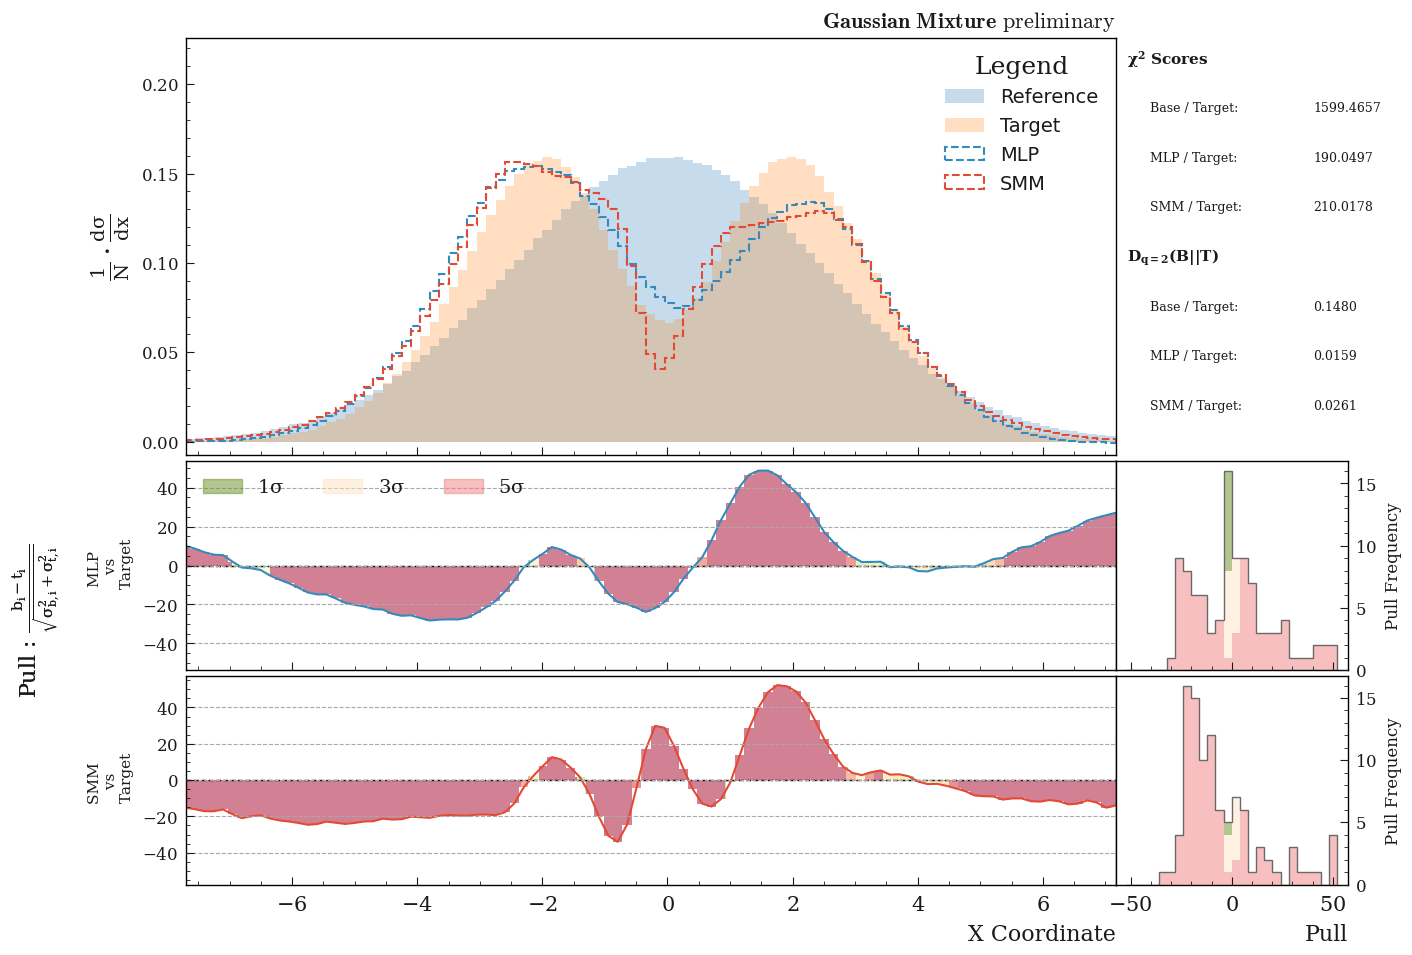

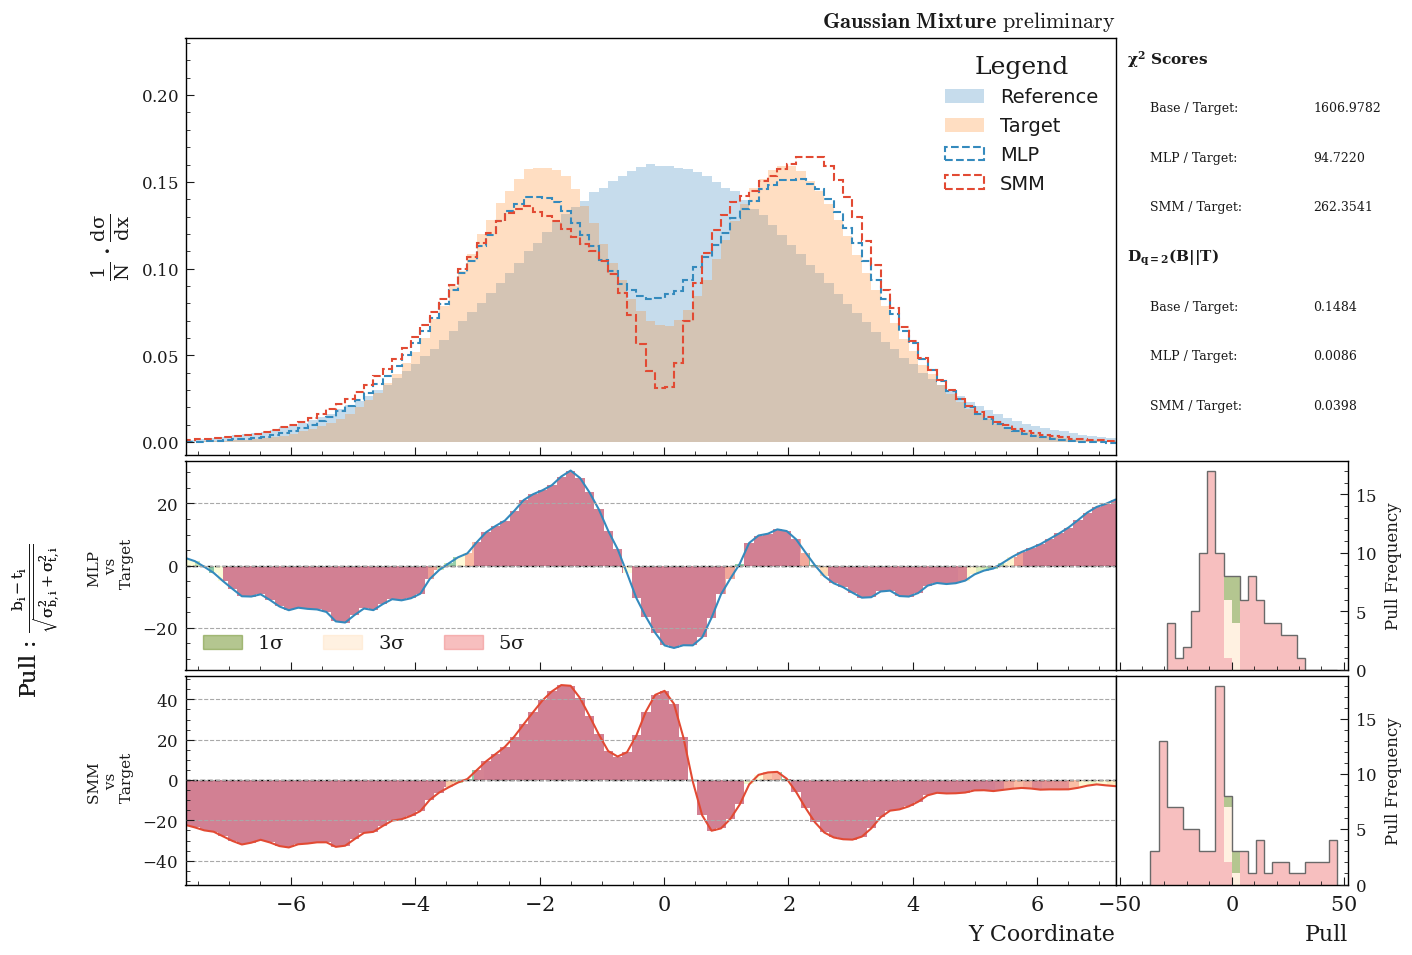

In [23]:
test_nominal_loader = DataLoader(utils.preprocessing.CombinedDataset(test_base_dataset), batch_size=batch_size, shuffle=False)
test_target_loader = DataLoader(utils.preprocessing.CombinedDataset(test_target_dataset), batch_size=batch_size, shuffle=False)

axes_labels = ["X Coordinate", "Y Coordinate"]
for i in range(2):
    test_nominal_loader.collate_fn = lambda batch: get_x_i(batch, i)
    test_target_loader.collate_fn = lambda batch: get_x_i(batch, i)

    test_nominal_xi = get_plot_data(test_nominal_loader)
    test_target_xi = get_plot_data(test_target_loader)

    kwargs={'legend.title_fontsize': 18, 'legend.fontsize': 14,
        'font.size': 14, 'axes.titlesize':20, 'axes.labelsize':16,'figure.titlesize':20, 'ytick.labelsize':12}
    carl_names = ["MLP", "SMM"]#, "$SMM_c$", "$SMM_r$"]
    r_hat_list = [r_hats_new, r_hats_SMM]#, r_hats_SMMc, r_hats_SMMr]
    utils.plotting.plot_distributions(test_nominal_xi[0], test_target_xi[0],
                                      test_nominal_xi[1], r_hat_list, test_target_xi[1],
                                      carl_names=carl_names,
                                      feature_name=axes_labels[i],
                                      nominal_name='Reference',
                                      alternate_name="Target",
                                      percentile_cuts=(0.1,99.99),
                                      nominal_mask=np.isfinite, alternate_mask=np.isfinite, carl_mask=np.isfinite, 
                                      logscale=False,
                                      typical_ratio = False,
                                      Tsallis_EMD=False,
                                      #ref_name = "Optimal",
                                      global_name = 'Gaussian Mixture',
                                      #saveAs = "Toy_{}_x{}_closure.pdf".format(DATASET, i),
                                      **kwargs  )

In [24]:
test_nominal_loader = DataLoader(utils.preprocessing.CombinedDataset(test_base_dataset), batch_size=batch_size, shuffle=False)
test_target_loader = DataLoader(utils.preprocessing.CombinedDataset(test_target_dataset), batch_size=batch_size, shuffle=False)

test_nominal_loader.collate_fn = lambda batch: get_r(batch)
test_target_loader.collate_fn = lambda batch: get_r(batch)

test_nominal_r = get_plot_data(test_nominal_loader)
test_target_r = get_plot_data(test_target_loader)

  0%|          | 0/13672 [00:00<?, ?it/s]

  0%|          | 0/13672 [00:00<?, ?it/s]

In [25]:
(r_hats_new < 0).sum()*100 / r_hats_new.shape[0], (r_hats_SMM < 0).sum()*100 / r_hats_SMM.shape[0]

(11.336228571428572, 7.136514285714286)

rcParams setting legend.title_fontsize  =  18
rcParams setting legend.fontsize  =  12
rcParams setting font.size  =  14
rcParams setting axes.titlesize  =  20
rcParams setting axes.labelsize  =  16
rcParams setting figure.titlesize  =  20
rcParams setting ytick.labelsize  =  14


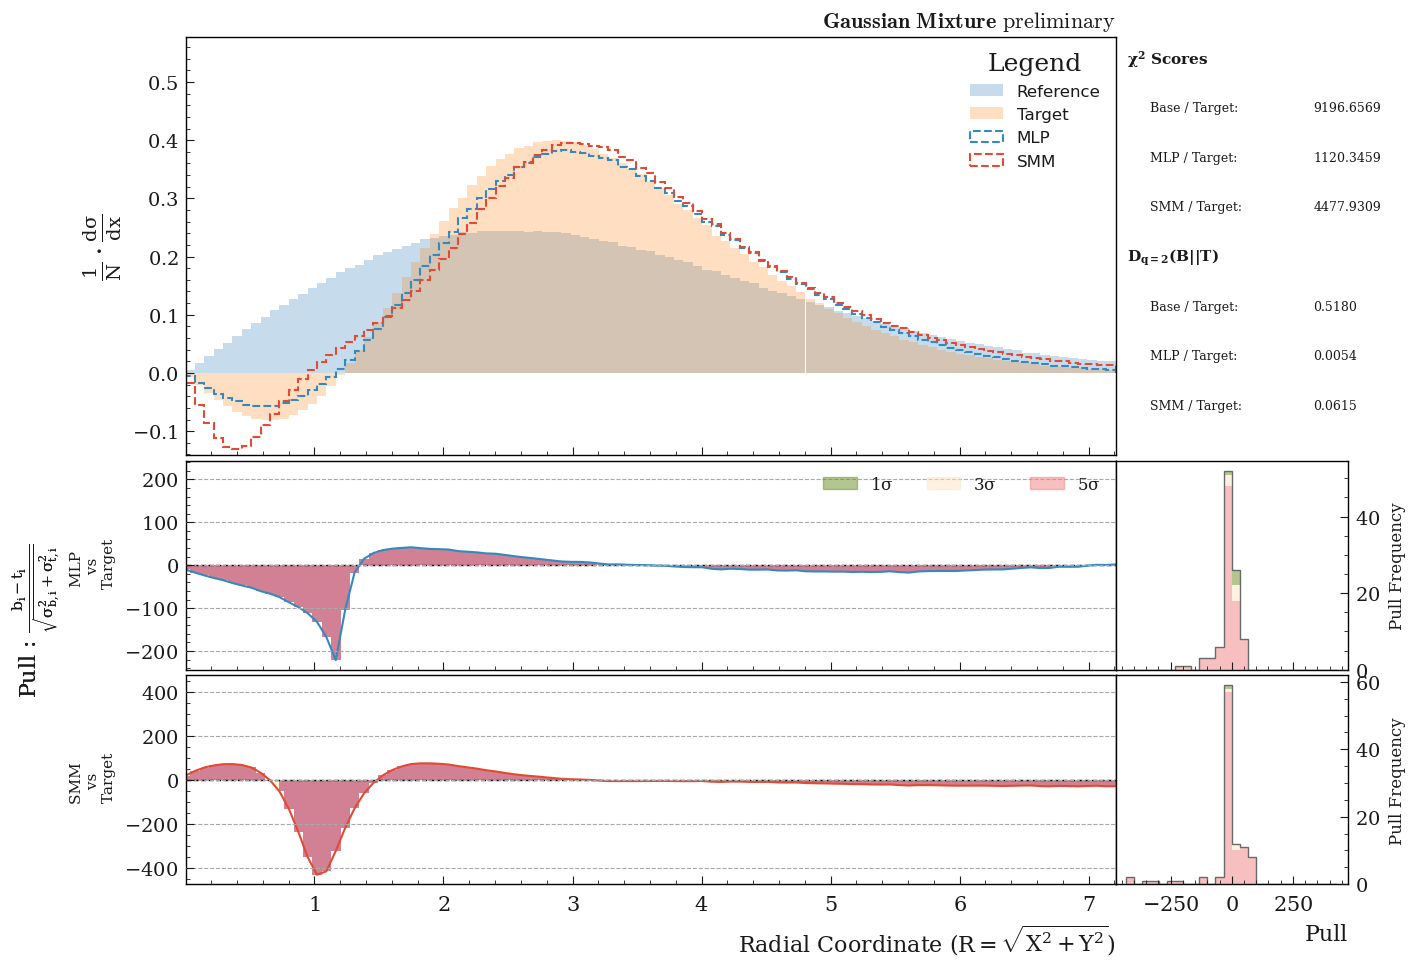

In [26]:
carl_names = ["MLP", "SMM"]#, "$SMM_c$", "$SMM_r$"]
r_hat_list = [r_hats_new, r_hats_SMM]#, r_hats_SMMc, r_hats_SMMr]
kwargs={'legend.title_fontsize': 18, 'legend.fontsize': 12,
        'font.size': 14, 'axes.titlesize':20, 'axes.labelsize':16,'figure.titlesize':20, 'ytick.labelsize':14}
utils.plotting.plot_distributions(test_nominal_r[0], test_target_r[0],
                   test_nominal_r[1] / np.mean(test_nominal_r[1]), r_hat_list, test_target_r[1] / np.mean(test_target_r[1]),
                   carl_names=carl_names,
                   feature_name="Radial Coordinate ($R = \sqrt{X^2+Y^2}$)", 
                   nominal_name='Reference',
                   alternate_name="Target",
                   percentile_cuts=(0, 99.9),
                   nominal_mask=np.isfinite, alternate_mask=np.isfinite, carl_mask=np.isfinite,
                   logscale=False,
                   typical_ratio = False,
                   Tsallis_EMD=False,
                   #ref_name = "Optimal",
                   global_name = 'Gaussian Mixture',
                   #saveAs = "Toy_{}_radial_closure.pdf".format(DATASET),
                   **kwargs);